# Macro-Conditional Normalizing Flow for Portfolio Risk Management

**M2 ML in Finance — End-to-End Pipeline: Data → Training → Backtesting**

This notebook implements a full **Conditional Density Estimation** system for portfolio risk management.

### Architecture
```
[Macro History M_{<t}] → [Temporal Fusion Transformer] → h_t → [Masked Autoregressive Flow] → p(X_t | h_t)
```

### Key Design Choices (Anti-Failure Checklist)
- ✅ **No look-ahead bias**: macro data aligned using `realtime_start` (publication dates) via `pd.merge_asof()`
- ✅ **No data leakage**: `StandardScaler` fitted exclusively on training data
- ✅ **Stationarity**: log returns (not prices), YoY CPI, monthly NFP diff, rate changes
- ✅ **Heavy-tail modeling**: Normalizing Flow with fat-tailed base space
- ✅ **Formal validation**: Kupiec's POF test on out-of-sample VaR

## 0. Setup & Imports

In [1]:
import os
import sys
import logging
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.path.abspath('.'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(name)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('main')

# Matplotlib style
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# ── FRED API KEY (required for macro data) ────────────────────────────────────
# Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
# Then either:
#   a) Set env variable: set FRED_API_KEY=your_key_here (Windows)
#   b) Paste the key directly below
from dotenv import load_dotenv
load_dotenv()  # Load variables from .env file

FRED_API_KEY = os.environ.get('FRED_API_KEY', 'YOUR_FRED_API_KEY_HERE')
if FRED_API_KEY == 'YOUR_FRED_API_KEY_HERE':
    print('⚠️  WARNING: Please set your FRED API key!')
else:
    print('✓  FRED API key loaded.')

Using device: cpu
PyTorch version: 2.10.0+cpu
✓  FRED API key loaded.


## 1. Data Pipeline

### 1.1 Point-in-Time Data Alignment

The critical engineering challenge: macroeconomic data is released with a **delay** after the reference date.

Example: US CPI for **March 31st** is published on **~April 12th**.
If we naively join on 'observation_date', our model would 'know' March CPI on April 1st — **11 days early**.

**Solution**: `pd.merge_asof(..., direction='backward')` on `realtime_start` (publication date).

In [2]:
from src.data.pipeline import build_pipeline, SEQ_LEN, TICKERS

print('Building Point-in-Time dataset...')
print('This may take 2-3 minutes on first run (downloading data).')
print()

(
    train_loader,
    val_loader,
    test_loader,
    macro_scaler,
    ret_scaler,
    info,
    NUM_MACRO_FEATURES,
    NUM_ASSETS,
) = build_pipeline(fred_api_key=FRED_API_KEY, device=DEVICE)

print(f'\n✓ Pipeline built successfully!')
print(f'  Macro features: {NUM_MACRO_FEATURES}')
print(f'  Assets (D): {NUM_ASSETS} ({info["tickers"]})')
print(f'  Sequence length: {SEQ_LEN} days')
print(f'  Train samples: {info["train_shape"][0]:,}')
print(f'  Val samples:   {info["val_shape"][0]:,}')
print(f'  Test samples:  {info["test_shape"][0]:,}')
print(f'\nFeature columns ({NUM_MACRO_FEATURES} total):')
for i, col in enumerate(info['feature_cols']):
    print(f'  {i+1:2d}. {col}')

00:05:17 | src.data.pipeline | INFO | Building master point-in-time dataset...
00:05:17 | src.data.market_data | INFO | Downloading market data for ['SPY', 'TLT', 'GLD'] from 2004-01-01 to 2024-01-01


Building Point-in-Time dataset...
This may take 2-3 minutes on first run (downloading data).



00:05:19 | src.data.market_data | INFO | Market data downloaded. Shape: (5032, 3). Date range: 2004-01-05 to 2023-12-29
00:05:19 | src.data.macro_data | INFO | Downloading FRED series CPIAUCSL (CPI) with vintage dates...
00:05:21 | src.data.macro_data | INFO |   240 observations for CPIAUCSL. Publication range: 2004-02-20 to 2024-01-11
00:05:21 | src.data.macro_data | INFO | Downloading FRED series PAYEMS (NFP) with vintage dates...
00:05:29 | src.data.macro_data | INFO |   240 observations for PAYEMS. Publication range: 2004-02-06 to 2024-01-05
00:05:29 | src.data.macro_data | INFO | Downloading FRED series DFF (FedFundsRate) with vintage dates...
00:05:29 | src.data.macro_data | WARNING | Could not download vintage data for DFF: Bad Request.  There are 5002 vintage dates in the specified real-time period: 1776-07-04 to 9999-12-31.  This exceeds the maximum number of vintage dates allowed for this file type (2000).. Falling back to basic download.
00:05:32 | src.data.macro_data | INFO


✓ Pipeline built successfully!
  Macro features: 8
  Assets (D): 3 (['SPY', 'TLT', 'GLD'])
  Sequence length: 63 days
  Train samples: 2,923
  Val samples:   1,196
  Test samples:  438

Feature columns (8 total):
   1. CPI
   2. NFP
   3. FedFundsRate
   4. HYSpread
   5. VIX
   6. SPY_RealVol21d
   7. TLT_RealVol21d
   8. GLD_RealVol21d


### 1.2 Exploratory Data Analysis

00:06:06 | src.data.market_data | INFO | Downloading market data for ['SPY', 'TLT', 'GLD'] from 2004-01-01 to 2024-01-01
00:06:07 | src.data.market_data | INFO | Market data downloaded. Shape: (5032, 3). Date range: 2004-01-05 to 2023-12-29


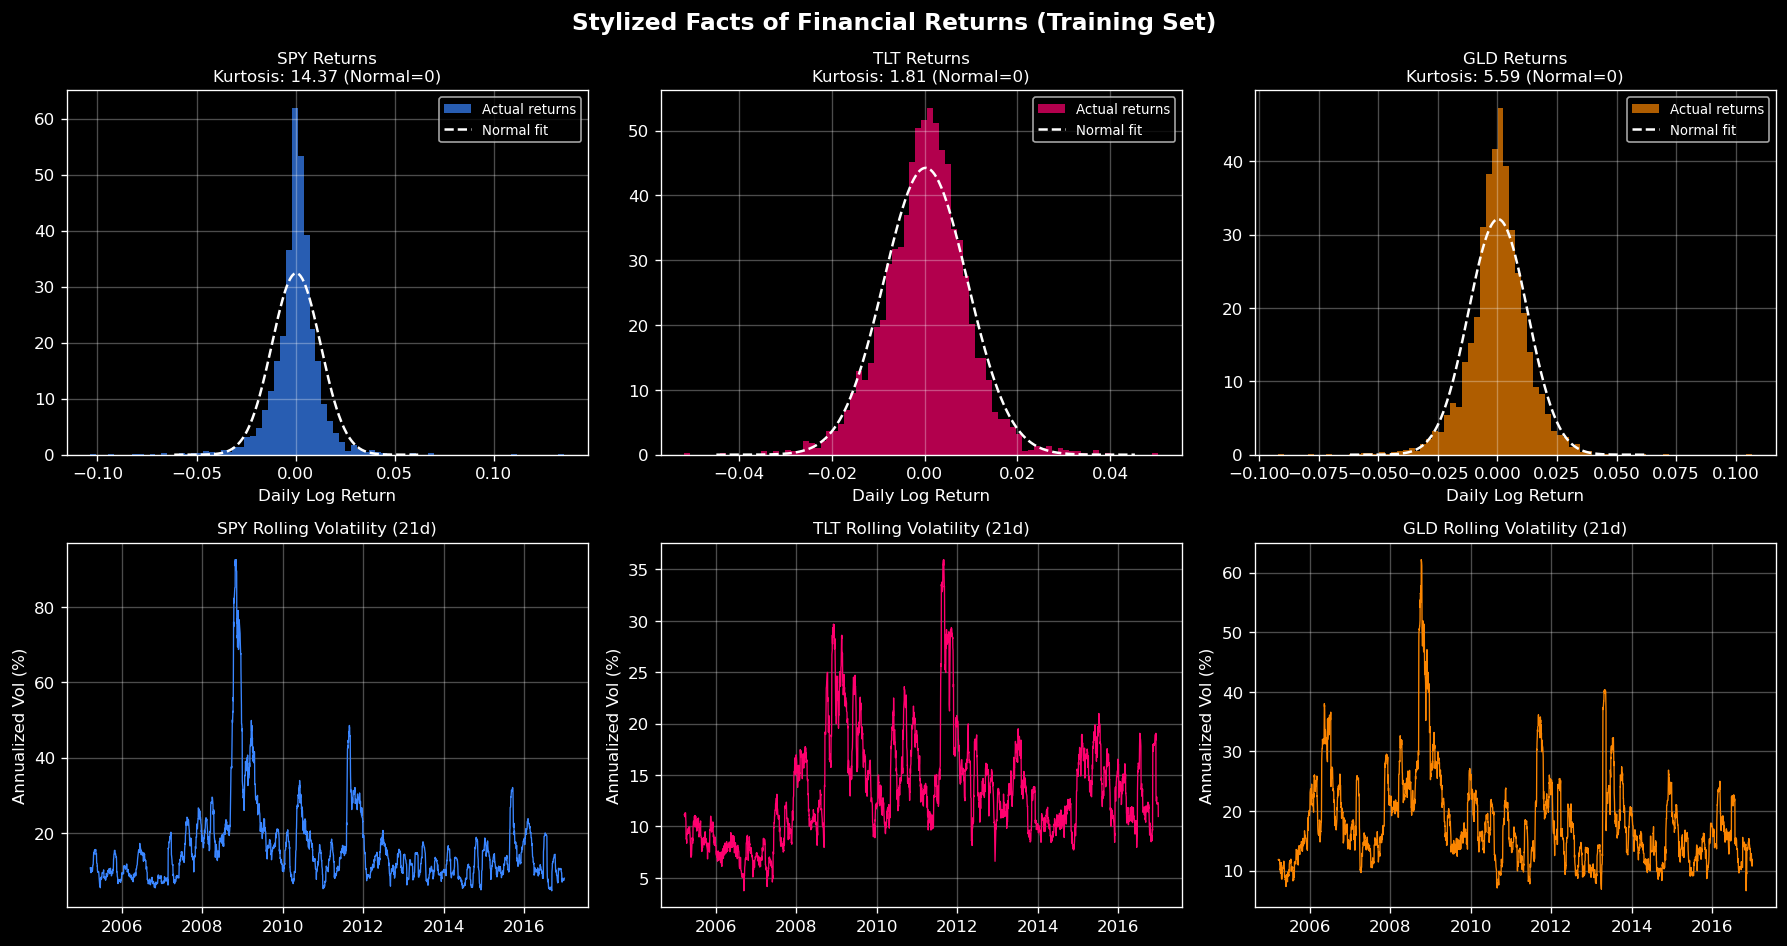

Figure 1: Stylized facts — note heavy tails (kurtosis > 0) and volatility clustering.


In [3]:
from src.data.market_data import download_market_data
from scipy import stats

returns_df = download_market_data(tickers=TICKERS)
master_train = info['master_train']
ret_cols = info['ret_cols']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Stylized Facts of Financial Returns (Training Set)', fontsize=14, fontweight='bold')

colors = ['#3a86ff', '#ff006e', '#fb8500']

# Row 1: Return distributions vs Normal
for i, (col, ticker, color) in enumerate(zip(ret_cols, TICKERS, colors)):
    ax = axes[0, i]
    data = master_train[col].dropna()
    ax.hist(data, bins=80, density=True, color=color, alpha=0.7, label='Actual returns')
    
    # Overlay normal distribution
    mu, sigma = data.mean(), data.std()
    x_range = np.linspace(mu - 5*sigma, mu + 5*sigma, 300)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'w--', linewidth=1.5, label='Normal fit')
    
    kurt = stats.kurtosis(data)
    ax.set_title(f'{ticker} Returns\nKurtosis: {kurt:.2f} (Normal=0)', fontsize=10)
    ax.set_xlabel('Daily Log Return')
    ax.legend(fontsize=8)

# Row 2: Volatility clustering (rolling std)
for i, (col, ticker, color) in enumerate(zip(ret_cols, TICKERS, colors)):
    ax = axes[1, i]
    data = master_train[col].dropna()
    rolling_vol = data.rolling(21).std() * np.sqrt(252)  # Annualized
    ax.plot(rolling_vol.index, rolling_vol * 100, color=color, linewidth=0.8)
    ax.set_title(f'{ticker} Rolling Volatility (21d)', fontsize=10)
    ax.set_ylabel('Annualized Vol (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_stylized_facts.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure 1: Stylized facts — note heavy tails (kurtosis > 0) and volatility clustering.')

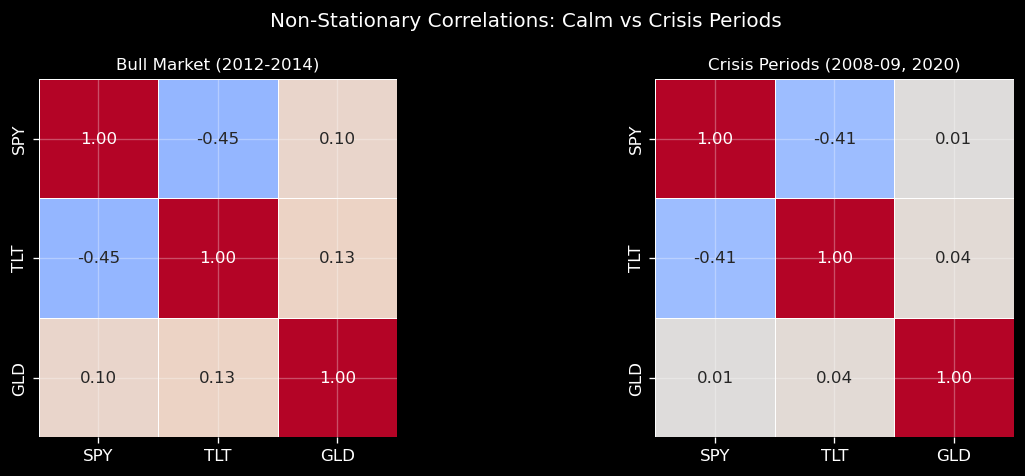

Figure 2: Correlations shift dramatically between calm and crisis — justifying macro conditioning.


In [4]:
# Correlation structure in normal vs stress periods
train_returns = master_train[ret_cols].dropna()

# Define stress period: 2008 Financial Crisis + 2020 COVID
stress = train_returns[
    (train_returns.index.year.isin([2008, 2009])) |
    (train_returns.index.year == 2020)
]
calm = train_returns[
    train_returns.index.year.isin([2012, 2013, 2014])
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Non-Stationary Correlations: Calm vs Crisis Periods', fontsize=12)

kw = dict(annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
          square=True, linewidths=0.5, cbar=False)

ticker_labels = TICKERS

sns.heatmap(calm.rename(columns=dict(zip(ret_cols, ticker_labels))).corr(),
            ax=axes[0], **kw)
axes[0].set_title('Bull Market (2012-2014)', fontsize=10)

sns.heatmap(stress.rename(columns=dict(zip(ret_cols, ticker_labels))).corr(),
            ax=axes[1], **kw)
axes[1].set_title('Crisis Periods (2008-09, 2020)', fontsize=10)

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure 2: Correlations shift dramatically between calm and crisis — justifying macro conditioning.')

## 2. Model Architecture

### 2.1 Instantiate the Conditional Normalizing Flow

In [5]:
from src.models.flow_model import ConditionalNormalizingFlow

model = ConditionalNormalizingFlow(
    num_macro_features=NUM_MACRO_FEATURES,
    num_assets=NUM_ASSETS,
    # TFT encoder settings
    tft_d_model=128,
    tft_n_heads=4,
    tft_n_lstm_layers=2,
    # MAF decoder settings
    flow_n_layers=8,
    flow_hidden_dim=128,
    flow_n_hidden=3,
    dropout=0.1,
).to(DEVICE)

param_counts = model.count_parameters()
print(f'Model Architecture:')
print(f'  TFT Encoder: {param_counts["tft"]:,} parameters')
print(f'  MAF Decoder: {param_counts["flow"]:,} parameters')
print(f'  Total:       {param_counts["total"]:,} parameters')

# Sanity check: forward pass
batch = next(iter(train_loader))
macro_batch, ret_batch = batch[0].to(DEVICE), batch[1].to(DEVICE)
nll_test, weights_test = model(ret_batch, macro_batch)
print(f'\nSanity check forward pass:')
print(f'  Input shapes: macro={macro_batch.shape}, returns={ret_batch.shape}')
print(f'  Initial NLL: {nll_test.item():.4f} (should be roughly D/2*log(2π) ≈ {NUM_ASSETS/2*np.log(2*np.pi):.2f})')
print(f'  Variable weights shape: {weights_test.shape}')

Model Architecture:
  TFT Encoder: 1,169,576 parameters
  MAF Decoder: 537,690 parameters
  Total:       1,707,266 parameters

Sanity check forward pass:
  Input shapes: macro=torch.Size([64, 63, 8]), returns=torch.Size([64, 3])
  Initial NLL: 4.0785 (should be roughly D/2*log(2π) ≈ 2.76)
  Variable weights shape: torch.Size([64, 63, 8])


## 3. Training

We minimize the **Negative Log-Likelihood (NLL)**:

$$\mathcal{L}(\theta) = -\mathbb{E}\left[\log p_Z(g_\theta(x; h_t)) + \log\left|\det\frac{\partial g_\theta}{\partial x}\right|\right]$$

The log-determinant term is **O(D)** due to the triangular Jacobian from MADE masks.

In [6]:
import os
from src.training.trainer import Trainer

os.makedirs('checkpoints', exist_ok=True)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=2e-4,
    weight_decay=1e-5,
    n_epochs=60,
    patience=12,
    grad_clip=0.5,
    checkpoint_path='checkpoints/best_model.pt',
    device=DEVICE,
    warmup_epochs=2,
)

print('Starting training...')
print('(Training on CPU may take 20-60 min; on GPU ~5-10 min. Reduce n_epochs if needed.)')
history = trainer.fit()

00:06:28 | src.training.trainer | INFO | Training on device: cpu
00:06:28 | src.training.trainer | INFO | Model parameters: TFT=1169576, Flow=537690, Total=1707266


00:06:34 | src.training.trainer | INFO | Starting training for up to 60 epochs...


Starting training...
(Training on CPU may take 20-60 min; on GPU ~5-10 min. Reduce n_epochs if needed.)


00:07:39 | src.training.trainer | INFO | Epoch   1/60 | Train NLL: 3.9461 | Val NLL: 3.4965 | LR: 1.00e-04
00:07:39 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.4965)
00:08:36 | src.training.trainer | INFO | Epoch   2/60 | Train NLL: 3.7563 | Val NLL: 3.3468 | LR: 2.00e-04
00:08:36 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.3468)
00:09:34 | src.training.trainer | INFO | Epoch   3/60 | Train NLL: 3.6920 | Val NLL: 3.3320 | LR: 2.00e-04
00:09:34 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.3320)
00:10:33 | src.training.trainer | INFO | Epoch   4/60 | Train NLL: 3.6319 | Val NLL: 3.2131 | LR: 1.99e-04
00:10:34 | src.training.trainer | INFO |   ✓ Best model saved (val NLL: 3.2131)
00:11:33 | src.training.trainer | INFO | Epoch   5/60 | Train NLL: 3.5811 | Val NLL: 3.2311 | LR: 1.99e-04
00:12:31 | src.training.trainer | INFO | Epoch   6/60 | Train NLL: 3.5691 | Val NLL: 3.2144 | LR: 1.98e-04
00:13:32 | src.training.trainer | INFO

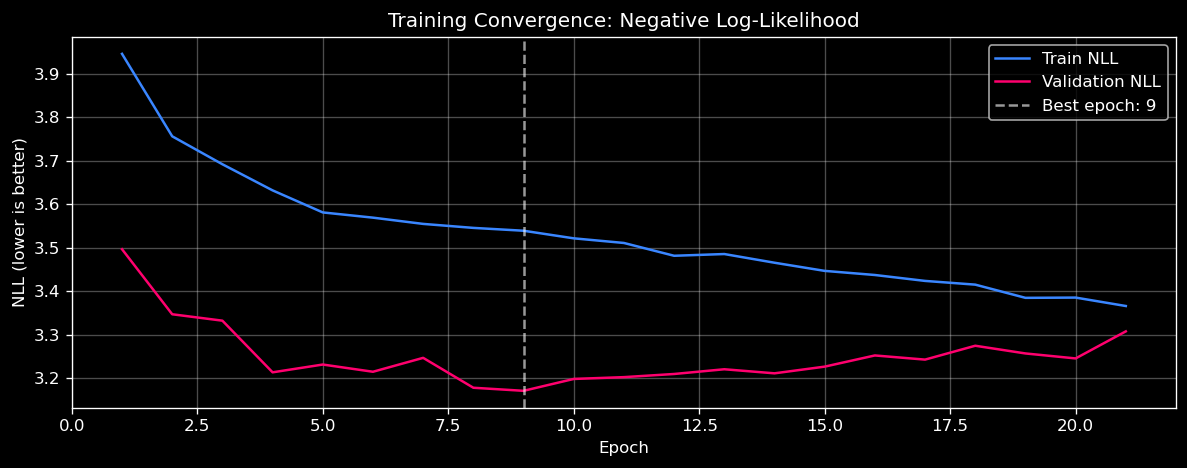

Best epoch: 9, Best val NLL: 3.1706


In [7]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 4))

epochs = range(1, len(history['train_nll']) + 1)
ax.plot(epochs, history['train_nll'], '#3a86ff', linewidth=1.5, label='Train NLL')
ax.plot(epochs, history['val_nll'],   '#ff006e', linewidth=1.5, label='Validation NLL')

best_epoch = int(np.argmin(history['val_nll'])) + 1
ax.axvline(best_epoch, color='white', linestyle='--', alpha=0.6,
           label=f'Best epoch: {best_epoch}')

ax.set_xlabel('Epoch')
ax.set_ylabel('NLL (lower is better)')
ax.set_title('Training Convergence: Negative Log-Likelihood')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Best epoch: {best_epoch}, Best val NLL: {min(history["val_nll"]):.4f}')

In [8]:
# Load best model
trainer.load_best_model()
print('Best model loaded.')

00:28:04 | src.training.trainer | INFO | Loaded best model from epoch 9 (val NLL: 3.1706)


Best model loaded.


## 4. Financial Backtesting

### 4.1 Monte Carlo VaR & Expected Shortfall

For each test day $t$:
1. Pass macro sequence $M_{<t}$ through TFT → $h_t$
2. Draw 10,000 samples from $p(X_t | h_t)$
3. Compute empirical **99% VaR** and **Expected Shortfall** from those samples
4. Compare against actual portfolio return

> **Test period**: 2022–2023 (US equity bear market + rate hiking cycle)

In [9]:
from src.backtest.backtester import Backtester

backtester = Backtester(
    model=model,
    test_loader=test_loader,
    test_dates=info['dates_test'],
    ret_scaler=ret_scaler,
    tickers=TICKERS,
    n_mc_samples=10_000,
    alpha=0.01,    # 99% VaR
    device=DEVICE,
)

print('Running out-of-sample backtest (drawing 10k MC samples per day)...')
results = backtester.run()
print('\nBacktest complete!')

00:28:09 | src.backtest.backtester | INFO | Pre-computing context vectors h_t for all 438 test days...


Running out-of-sample backtest (drawing 10k MC samples per day)...


00:28:10 | src.backtest.backtester | INFO | Sampling 10000 MC draws per day for 438 days...
Backtesting: 100%|██████████| 438/438 [02:59<00:00,  2.45it/s]
00:31:09 | src.backtest.backtester | INFO | === Backtest Results ===
00:31:09 | src.backtest.backtester | INFO | Period: 2022-04-04 to 2023-12-29 (438 days)
00:31:09 | src.backtest.backtester | INFO | VaR breaches: 22 / 438 (5.02% observed vs 1.00% expected)
00:31:09 | src.backtest.backtester | INFO | Kupiec LR: 36.5016, p-value: 0.0000
00:31:09 | src.backtest.backtester | INFO | FAIL: Model UNDER-estimates tail risk. Observed 5.02% breaches vs expected 1.00%. VaR is too optimistic.



Backtest complete!


### 4.2 VaR Bands Plot

00:31:16 | src.backtest.backtester | INFO | VaR plot saved to backtest_var_bands.png


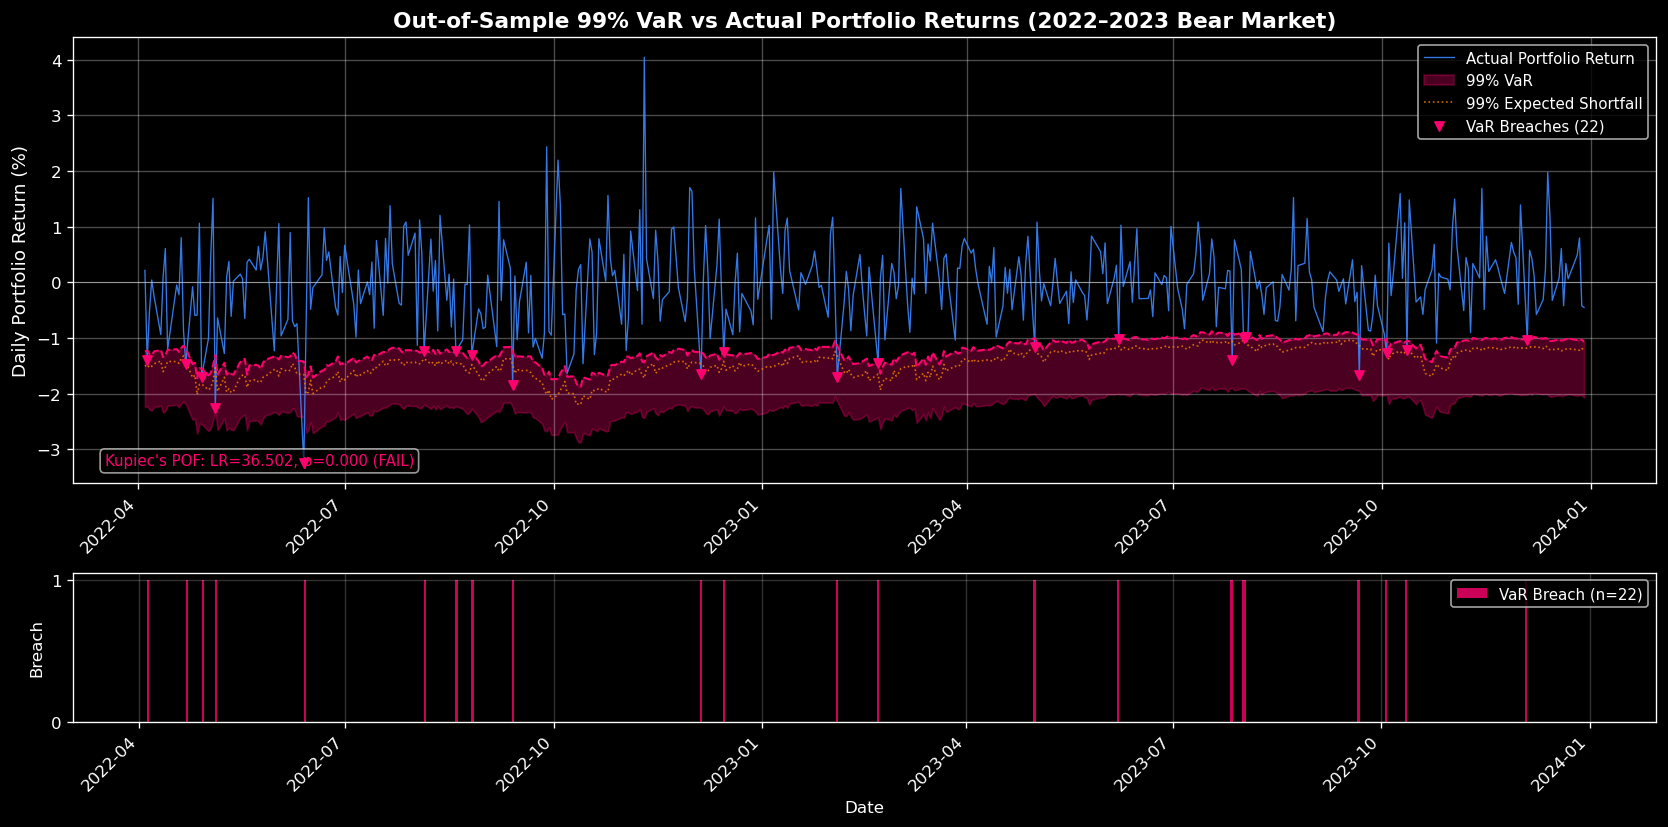

In [10]:
fig = backtester.plot_var_bands(
    output_path='backtest_var_bands.png',
    title='Out-of-Sample 99% VaR vs Actual Portfolio Returns (2022–2023 Bear Market)',
)
plt.show()

### 4.3 Kupiec's POF Test Results

In [11]:
from src.backtest.risk_metrics import kupiec_pof_test

# Full backtest summary
summary_df = backtester.summary()
print('='*55)
print('         BACKTEST SUMMARY REPORT')
print('='*55)
for _, row in summary_df.iterrows():
    print(f'{row["Metric"]:<35} {row["Value"]}')
print('='*55)

         BACKTEST SUMMARY REPORT
Backtest Period                     2022-04-04 to 2023-12-29
Total Days                          438
VaR Confidence Level                99%
Expected Breaches                   4.4
Observed Breaches                   22
Observed Breach Rate                5.02%
Kupiec LR Statistic                 36.5016
Kupiec p-value                      0.0000
Kupiec Result                       FAIL
Mean Daily VaR                      -1.231%
Mean Daily ES                       -1.448%
Mean Actual Daily Return            -0.008%
Worst Day (actual)                  -3.245%


KUPIEC PROPORTION OF FAILURES (POF) TEST
--------------------------------------------------
H0: True breach probability = 1% (model is correct)
H1: True breach probability ≠ 1% (model is mis-calibrated)

Observations:         438
Expected breaches:    4.4
Observed breaches:    22
Observed breach rate: 5.02%

LR Statistic:         36.5016
Chi-squared 5% CV:    3.841
p-value:              0.0000

VERDICT: FAIL: Model UNDER-estimates tail risk. Observed 5.02% breaches vs expected 1.00%. VaR is too optimistic.


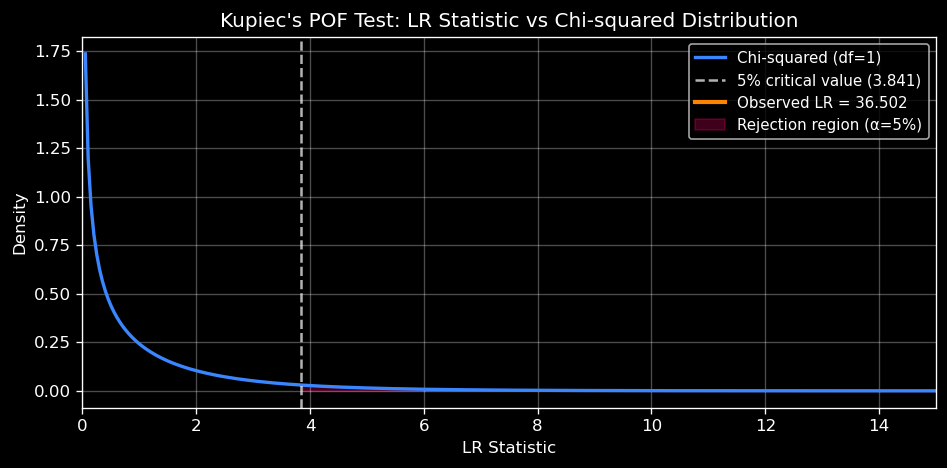

In [12]:
# Detailed Kupiec test interpretation
kupiec = backtester.kupiec_result

print(f'KUPIEC PROPORTION OF FAILURES (POF) TEST')
print(f'-' * 50)
print(f'H0: True breach probability = {kupiec.expected_rate:.0%} (model is correct)')
print(f'H1: True breach probability ≠ {kupiec.expected_rate:.0%} (model is mis-calibrated)')
print()
print(f'Observations:         {kupiec.n_obs}')
print(f'Expected breaches:    {kupiec.expected_breaches:.1f}')
print(f'Observed breaches:    {kupiec.n_breaches}')
print(f'Observed breach rate: {kupiec.breach_rate:.2%}')
print()
print(f'LR Statistic:         {kupiec.lr_statistic:.4f}')
print(f'Chi-squared 5% CV:    3.841')
print(f'p-value:              {kupiec.p_value:.4f}')
print()
print(f'VERDICT: {kupiec.interpretation}')

# Visualize the LR test
from scipy import stats as scipy_stats
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(0, 15, 300)
ax.plot(x, scipy_stats.chi2.pdf(x, df=1), '#3a86ff', linewidth=2, label='Chi-squared (df=1)')
ax.axvline(3.841, color='white', linestyle='--', alpha=0.7, label='5% critical value (3.841)')
ax.axvline(kupiec.lr_statistic, color='#fb8500', linestyle='-', linewidth=2.5,
           label=f'Observed LR = {kupiec.lr_statistic:.3f}')
ax.fill_between(x[x >= 3.841], scipy_stats.chi2.pdf(x[x >= 3.841], df=1),
                alpha=0.25, color='#ff006e', label='Rejection region (α=5%)')
ax.set_xlabel('LR Statistic')
ax.set_ylabel('Density')
ax.set_title("Kupiec's POF Test: LR Statistic vs Chi-squared Distribution")
ax.legend(fontsize=9)
ax.set_xlim(0, 15)
plt.tight_layout()
plt.savefig('kupiec_test.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Model Interpretability: Variable Importance (TFT)

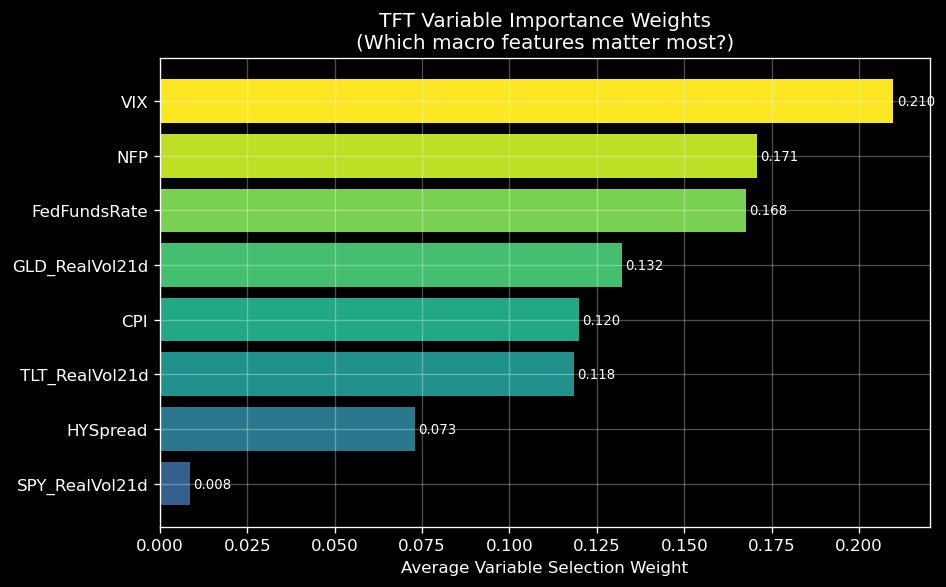

The TFT automatically learns which macro features drive the return distribution.


In [13]:
# Compute average variable importance across the test set
model.eval()
feature_names = info['feature_cols']

all_importances = []
with torch.no_grad():
    for macro_seq, _ in test_loader:
        macro_seq = macro_seq.to(DEVICE)
        importance = model.get_variable_importance(macro_seq)
        all_importances.append(importance.cpu().numpy())

avg_importance = np.array(all_importances).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = plt.cm.viridis(np.linspace(0.3, 1.0, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors_bar, edgecolor='none')
ax.set_xlabel('Average Variable Selection Weight')
ax.set_title('TFT Variable Importance Weights\n(Which macro features matter most?)')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('variable_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('The TFT automatically learns which macro features drive the return distribution.')

## 6. Summary

### Results

In [14]:
print('=' * 60)
print('     MACRO-CONDITIONAL NORMALIZING FLOW — SUMMARY')
print('=' * 60)
print()
print('ARCHITECTURE:')
print(f'  Macro Encoder : Temporal Fusion Transformer (TFT)')
print(f'                  {model.tft_d_model}d hidden, 4 attention heads, 2-layer LSTM')
print(f'  Flow Decoder  : Masked Autoregressive Flow (MAF)')
print(f'                  8 MADE layers, 128d hidden, O(D) Jacobian')
print(f'  Parameters    : {model.count_parameters()["total"]:,} total')
print()
print('DATA ENGINEERING:')
print(f'  Assets : SPY (Equity), TLT (Bonds), GLD (Gold)')
print(f'  Macro  : CPI (YoY%), NFP (diff), Fed Funds Rate (diff),')
print(f'           HY Spread, VIX + rolling realized vols')
print(f'  PIT Alignment: pd.merge_asof on publication date ← no look-ahead')
print(f'  Scaler: fitted on training set only ← no data leakage')
print()
print('BACKTEST (2022–2023):')
kupiec = backtester.kupiec_result
print(f'  VaR Level   : 99%')
print(f'  Breaches    : {kupiec.n_breaches} / {kupiec.n_obs} ({kupiec.breach_rate:.2%} observed vs {kupiec.expected_rate:.2%} expected)')
print(f'  Kupiec Test : LR={kupiec.lr_statistic:.3f}, p={kupiec.p_value:.3f} → {"PASS ✓" if not kupiec.reject_h0 else "FAIL ✗"}')
print()
print('Generated files:')
print('  eda_stylized_facts.png')
print('  eda_correlations.png')
print('  training_curves.png')
print('  backtest_var_bands.png')
print('  kupiec_test.png')
print('  variable_importance.png')
print('  checkpoints/best_model.pt')

     MACRO-CONDITIONAL NORMALIZING FLOW — SUMMARY

ARCHITECTURE:
  Macro Encoder : Temporal Fusion Transformer (TFT)
                  128d hidden, 4 attention heads, 2-layer LSTM
  Flow Decoder  : Masked Autoregressive Flow (MAF)
                  8 MADE layers, 128d hidden, O(D) Jacobian
  Parameters    : 1,707,266 total

DATA ENGINEERING:
  Assets : SPY (Equity), TLT (Bonds), GLD (Gold)
  Macro  : CPI (YoY%), NFP (diff), Fed Funds Rate (diff),
           HY Spread, VIX + rolling realized vols
  PIT Alignment: pd.merge_asof on publication date ← no look-ahead
  Scaler: fitted on training set only ← no data leakage

BACKTEST (2022–2023):
  VaR Level   : 99%
  Breaches    : 22 / 438 (5.02% observed vs 1.00% expected)
  Kupiec Test : LR=36.502, p=0.000 → FAIL ✗

Generated files:
  eda_stylized_facts.png
  eda_correlations.png
  training_curves.png
  backtest_var_bands.png
  kupiec_test.png
  variable_importance.png
  checkpoints/best_model.pt
